In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
import math

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
# Drop the zero coulmns
zero_cols = ['zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16',"zero.17",	"zero.18"]

df = df.drop(df[zero_cols].columns[((df[zero_cols] == 0).sum() == 1309)], axis=1)

In [4]:
# Change the Sex to "Male" and "Female" assuming 0 is for Male and 1 Female

df.loc[(df['Sex'] == 0), 'Sex'] = "Male"
df.loc[(df['Sex'] == 1), 'Sex'] = "Female"
df['Sex'] = df['Sex'].astype(str)

/tmp/nix-shell-6972-183411116/ipykernel_7333/1799391176.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Male' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['Sex'] == 0), 'Sex'] = "Male"


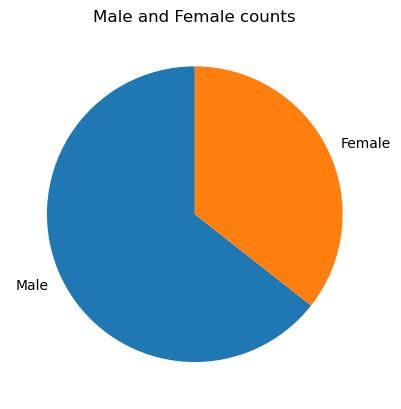

In [5]:
# Male and Female counts
m = df.loc[(df['Sex'] == "Male"), 'Sex'].count()
f = df.loc[(df['Sex'] == "Female"), 'Sex'].count()
y = np.array([m,f])

plt.title("Male and Female counts")
plt.pie(y, labels = ["Male","Female"], startangle = 90)
plt.show() 

In [6]:
df = df.rename(columns={"2urvived": "Survived"})

In [7]:
df.loc[(df['Survived'] == 1), 'Survived'] = "Survived"
df.loc[(df['Survived'] == 0), 'Survived'] = "Died"
df['Survived'] = df['Survived'].astype(str)

/tmp/nix-shell-6972-183411116/ipykernel_7333/129401851.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Survived' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['Survived'] == 1), 'Survived'] = "Survived"


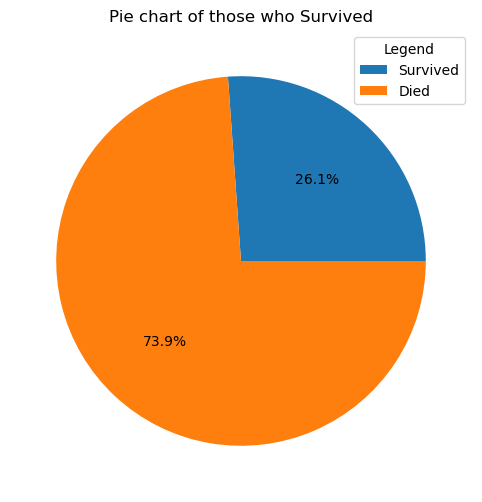

In [8]:
# Pie chart of those| who Survived
s = df.loc[(df['Survived'] == "Survived"), 'Survived'].count()
d = df.loc[(df['Survived'] == "Died"), 'Survived'].count()
y = np.array([s,d])

plt.figure(figsize=(8, 6))
plt.pie(y, autopct='%1.1f%%')
plt.legend(["Survived","Died"], title="Legend")
plt.title("Pie chart of those who Survived")
plt.show() 

Text(0.5, 1.0, 'Gender with the most death')

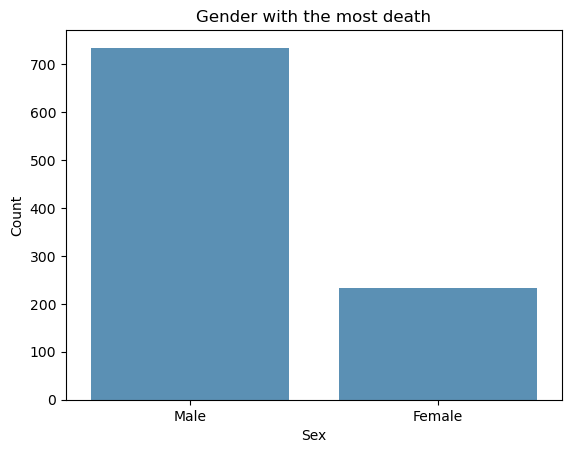

In [9]:
md = df.loc[(df['Survived'] == "Died") & (df['Sex'] == "Male"), 'Survived'].count()
fd = df.loc[(df['Survived'] == "Died") & (df['Sex'] == "Female"), 'Survived'].count()
df2 = pd.DataFrame({
    "Sex": ["Male", "Female"],
    "Count": [md, fd]
})
sns.barplot(data=df2, x="Sex", y="Count", alpha=0.8)
plt.title("Gender with the most death")

Text(0, 0.5, 'Number of Passengers')

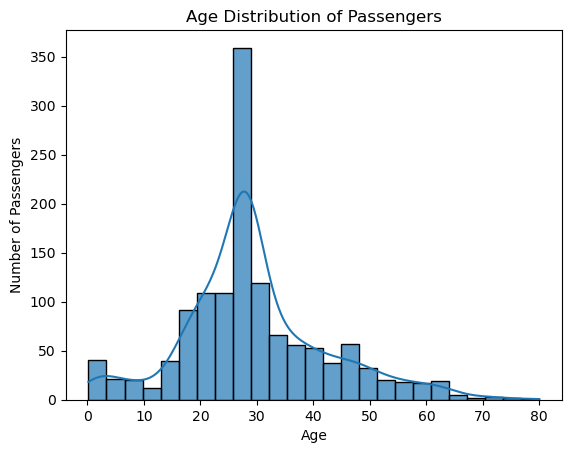

In [39]:
sns.histplot(data=df, x='Age', bins=25, alpha=0.7, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

In [108]:
# Did passengers who paid higher fares have better survival rates?

# Grouping of data
d = (df.Survived == "Died")
s = (df.Survived == "Survived")
da = df[s].groupby("Fare")["Survived"].count()

more = da[da.index >= 50]
less = da[da.index < 50]
m1 = (more["Survived"] == "Survived").mean()  
l1 = (less["Survived"] == "Survived").mean()

# Null and Alternative Hypothesis
## H0: Paying more than 50 does not affect survial chance
## HA: Paying more than 50 affect survial chance

a = 0.05
rz = stats.norm.ppf(1 - a)
#lz = stats.norm.ppf(a)

def test_stat(x, mean, std,n):
    z = (x - mean) / (std / math.sqrt(n))
    return z

x = test_stat(l1,m1,more.std(),more.count())

print(x,rz)
print("Reject H0 in favor of HA")
#print(more.count())   


KeyError: 'Survived'

0         7.2500
1        71.2833
2         7.9250
3        53.1000
4         8.0500
          ...   
1304      8.0500
1305    108.9000
1306      7.2500
1307      8.0500
1308     22.3583
Name: Fare, Length: 1309, dtype: float64